**Visual Lead**

Input: `01_Processed_Data/metadata.csv` + `01_Processed_Data/images/*.jpg` from Data Lead (notebook 01).

Output (saved to `02_Embeddings/`):
- `image_ib_embeddings.npy` — ImageBind Vision (generalist), shape `(150, 1024)`, float32
- `image_clip_embeddings.npy` — CLIP ViT-B/32 (specialist), shape `(150, 512)`, float32

Goal: produce two row-aligned visual embedding matrices for the Multimodal Triangle comparison in notebooks 05 and 06.


Run all once data processing is complete.

In [ ]:
# 1. Connect to Google Drive & Core Imports
from google.colab import drive
import os, shutil, random
from datetime import datetime
import pandas as pd
import numpy as np
import torch

drive.mount('/content/drive')

# 2. Canonical project paths
PROJECT_ROOT = "/content/drive/MyDrive/DL_Project_2026"

PROCESSED_DIR  = os.path.join(PROJECT_ROOT, "01_Processed_Data")
EMBED_DIR      = os.path.join(PROJECT_ROOT, "02_Embeddings")
VIS_DIR        = os.path.join(PROJECT_ROOT, "04_Visual_Checks")
VERSIONS_ROOT  = os.path.join(PROJECT_ROOT, "99_Versions")

NOTEBOOK_ID = "03"

for d in (EMBED_DIR, VIS_DIR, VERSIONS_ROOT):
    os.makedirs(d, exist_ok=True)

# 3. Seed everything (used by seeded-random heatmap sample + downstream UMAP)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4. Archive primitives (shared signature across all six notebooks)
def archive_previous_run(directory_path, notebook_id):
    if os.path.exists(directory_path) and os.listdir(directory_path):
        stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
        folder_name = os.path.basename(directory_path)
        archive_name = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{folder_name}")
        os.makedirs(VERSIONS_ROOT, exist_ok=True)
        print(f"📦 Archiving previous {folder_name} to: {archive_name}")
        shutil.move(directory_path, archive_name)
    os.makedirs(directory_path, exist_ok=True)

def archive_files(file_paths, notebook_id):
    movers = [p for p in file_paths if os.path.exists(p)]
    if not movers:
        return
    stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    parent_name = os.path.basename(os.path.dirname(movers[0]))
    out_dir = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{parent_name}")
    os.makedirs(out_dir, exist_ok=True)
    for p in movers:
        shutil.move(p, os.path.join(out_dir, os.path.basename(p)))
    print(f"📦 Archived {len(movers)} file(s) to {out_dir}")

# 5. Device check + fallback warning
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("⚠️  Running on CPU — ImageBind huge + CLIP on 150 images will be slow.")
    print("    Fix: Runtime → Change runtime type → GPU.")
else:
    props = torch.cuda.get_device_properties(0)
    print(f"✅ Device: {device} | {torch.cuda.get_device_name(0)} | {props.total_memory / 1e9:.1f} GB")

print(f"✅ Notebook {NOTEBOOK_ID} setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda | Tesla T4 | 15.6 GB
✅ Notebook 03 setup complete.


In [ ]:
# --- UPSTREAM CONTRACT CHECK (notebook 01 must have run) ---
metadata_path = f"{PROCESSED_DIR}/metadata.csv"

# --- Debugging --- BEGIN
print(f"DEBUG: metadata_path = {metadata_path}")
print(f"DEBUG: PROCESSED_DIR exists = {os.path.exists(PROCESSED_DIR)}")
if os.path.exists(PROCESSED_DIR):
    print(f"DEBUG: Contents of PROCESSED_DIR: {os.listdir(PROCESSED_DIR)}")
else:
    print(f"DEBUG: PROCESSED_DIR does not exist: {PROCESSED_DIR}")
# --- Debugging --- END

assert os.path.exists(metadata_path), f"metadata.csv not found at {metadata_path}. Run notebook 01 first."

metadata = pd.read_csv(metadata_path)

REQUIRED_COLS = [
    "track_id", "file_name", "song_title", "artist_name", "genre",
    "emotion_category", "emotion_subcategory", "contributor",
    "standardized_audio_path", "standardized_image_path", "lyrics_path",
]
missing_cols = [c for c in REQUIRED_COLS if c not in metadata.columns]
assert not missing_cols, f"metadata.csv missing columns {missing_cols} — rerun notebook 01."
assert metadata["track_id"].is_unique, "Duplicate track_id in metadata.csv"

image_paths = [os.path.join(PROCESSED_DIR, "images", f"{tid}.jpg") for tid in metadata["track_id"]]
missing_imgs = [p for p in image_paths if not os.path.exists(p)]
assert not missing_imgs, f"Missing {len(missing_imgs)} processed JPGs (first: {missing_imgs[:3]}) — rerun notebook 01."

print(f"✅ Upstream contract OK — {len(metadata)} images ready for visual embedding.")

DEBUG: metadata_path = /content/drive/MyDrive/DL_Project_2026/01_Processed_Data/metadata.csv
DEBUG: PROCESSED_DIR exists = True
DEBUG: Contents of PROCESSED_DIR: ['audio', 'images', 'lyrics', 'metadata.csv']
✅ Upstream contract OK — 150 images ready for visual embedding.


In [ ]:
# --- STEP 1: INSTALL MODELS ---
# NOTE: HEAD pins only; reproducibility freeze deferred (ASK A-1 in triage).
!pip install -q git+https://github.com/openai/CLIP.git git+https://github.com/facebookresearch/ImageBind.git

import clip
from PIL import Image
from imagebind import data as ib_data
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType

# --- STEP 2: LOAD MODELS ---
print("🖼️  Loading CLIP ViT-B/32 + ImageBind huge ...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model = clip_model.eval()  # explicit, future-proof
ib_model = imagebind_model.imagebind_huge(pretrained=True).to(device).eval()

# --- STEP 3: EXTRACT IMAGEBIND VISION (BATCHED) ---
BATCH = 32
print(f"🧠 ImageBind Vision in batches of {BATCH} ...")
ib_chunks = []
for i in range(0, len(image_paths), BATCH):
    batch_paths = image_paths[i : i + BATCH]
    batch_tensor = ib_data.load_and_transform_vision_data(batch_paths, device)
    with torch.no_grad():
        out = ib_model({ModalityType.VISION: batch_tensor})
    ib_chunks.append(out[ModalityType.VISION].detach().cpu().numpy().astype(np.float32))
    del batch_tensor, out
    if device == "cuda":
        torch.cuda.empty_cache()
image_ib = np.concatenate(ib_chunks, axis=0)
print(f"   ImageBind vision: {image_ib.shape}")

# --- STEP 4: EXTRACT CLIP VISION (BATCHED, RGB-safe) ---
# NOTE: clip.load on CUDA returns a fp16 model — we explicitly cast features to float32
#       before saving for a consistent dtype across all six embedding files.
print(f"🎨 CLIP ViT-B/32 vision in batches of {BATCH} ...")
clip_chunks = []
for i in range(0, len(image_paths), BATCH):
    batch_paths = image_paths[i : i + BATCH]
    tensors = torch.stack([
        clip_preprocess(Image.open(p).convert("RGB")) for p in batch_paths
    ]).to(device)
    with torch.no_grad():
        feats = clip_model.encode_image(tensors)
    clip_chunks.append(feats.detach().cpu().float().numpy().astype(np.float32))
    del tensors, feats
    if device == "cuda":
        torch.cuda.empty_cache()
image_clip = np.concatenate(clip_chunks, axis=0)
print(f"   CLIP vision:      {image_clip.shape}")

# --- STEP 5: SHAPE / FINITE / DTYPE ASSERTIONS ---
EXPECTED_IB_DIM = 1024
EXPECTED_CLIP_DIM = 512
N = len(metadata)

assert image_ib.shape == (N, EXPECTED_IB_DIM), f"image_ib wrong shape: {image_ib.shape}"
assert image_clip.shape == (N, EXPECTED_CLIP_DIM), f"image_clip wrong shape: {image_clip.shape}"
assert image_ib.dtype == np.float32 and image_clip.dtype == np.float32, "embeddings must be float32"
assert np.isfinite(image_ib).all(), "image_ib contains NaN/Inf"
assert np.isfinite(image_clip).all(), "image_clip contains NaN/Inf"

# --- STEP 6: ARCHIVE (file-scoped) THEN SAVE ---
image_ib_path   = os.path.join(EMBED_DIR, "image_ib_embeddings.npy")
image_clip_path = os.path.join(EMBED_DIR, "image_clip_embeddings.npy")

archive_files([image_ib_path, image_clip_path], notebook_id=NOTEBOOK_ID)

np.save(image_ib_path,   image_ib)
np.save(image_clip_path, image_clip)
# NOTE: ImageBind vectors are L2 normalized by the ImageBind library itself.
#       CLIP vectors are un-normalized; notebook 05 handles L2 normalization before cosine.

print(f"✅ Saved {image_ib_path}  {image_ib.shape}")
print(f"✅ Saved {image_clip_path} {image_clip.shape}")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
🖼️  Loading CLIP ViT-B/32 + ImageBind huge ...
🧠 ImageBind Vision in batches of 32 ...
   ImageBind vision: (150, 1024)
🎨 CLIP ViT-B/32 vision in batches of 32 ...
   CLIP vision:      (150, 512)
📦 Archived 2 file(s) to /content/drive/MyDrive/DL_Project_2026/99_Versions/03_2026-04-21_20-33_02_Embeddings
✅ Saved /content/drive/MyDrive/DL_Project_2026/02_Embeddings/image_ib_embeddings.npy  (150, 1024)
✅ Saved /content/drive/MyDrive/DL_Project_2026/02_Embeddings/image_clip_embeddings.npy (150, 512)


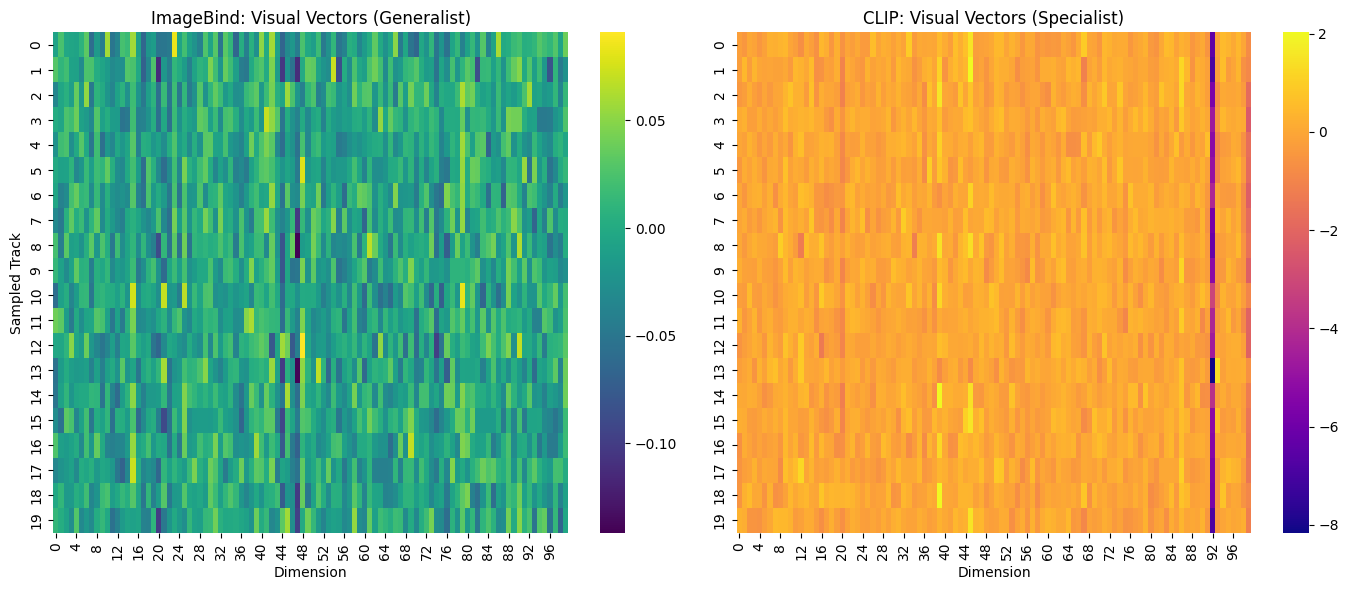

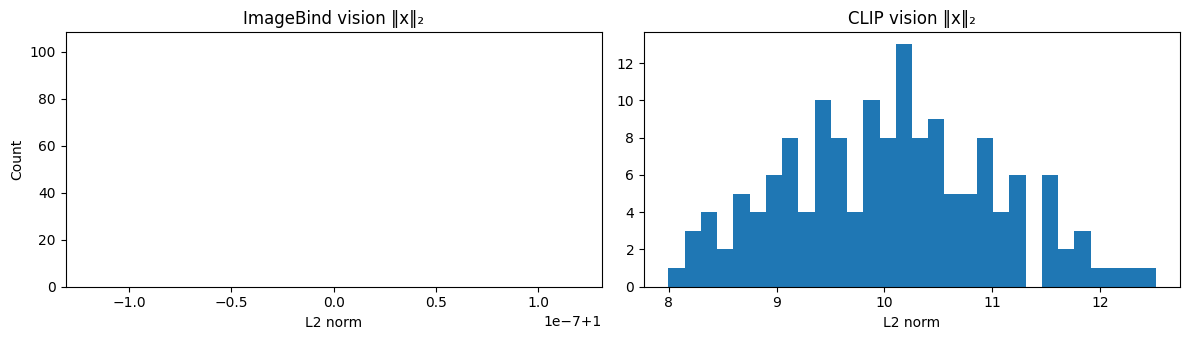

✅ Visual checks saved to /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/03_2026-04-21_20-33
✅ Notebook 03 complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Timestamped visual-check subfolder
stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
vis_out = os.path.join(VIS_DIR, f"{NOTEBOOK_ID}_{stamp}")
os.makedirs(vis_out, exist_ok=True)

image_ib   = np.load(os.path.join(EMBED_DIR, "image_ib_embeddings.npy"))
image_clip = np.load(os.path.join(EMBED_DIR, "image_clip_embeddings.npy"))

# ----- (a) Side-by-side embedding heatmaps (seeded random 20-track sample) -----
rng = np.random.RandomState(SEED)
idx = rng.choice(len(image_ib), size=20, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(image_ib[idx, :100],   ax=axes[0], cmap='viridis', cbar=True)
axes[0].set(title="ImageBind: Visual Vectors (Generalist)", xlabel="Dimension", ylabel="Sampled Track")
sns.heatmap(image_clip[idx, :100], ax=axes[1], cmap='plasma',  cbar=True)
axes[1].set(title="CLIP: Visual Vectors (Specialist)",      xlabel="Dimension")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "visual_embedding_comparison.png"), dpi=150)
plt.show()

# ----- (b) Per-track norm histograms (dead-image detector) -----
norms_ib   = np.linalg.norm(image_ib,   axis=1)
norms_clip = np.linalg.norm(image_clip, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(norms_ib,   bins=30); axes[0].set(title="ImageBind vision ‖x‖₂", xlabel="L2 norm", ylabel="Count")
axes[1].hist(norms_clip, bins=30); axes[1].set(title="CLIP vision ‖x‖₂",      xlabel="L2 norm")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "vision_norms.png"), dpi=150)
plt.show()

print(f"✅ Visual checks saved to {vis_out}")
print("✅ Notebook 03 complete.")


### Investigating ImageBind Embedding Normalization

The code comment in the previous cell (`o4r6CkqEgi3P`) states:
`# NOTE: vectors saved UN-normalized; notebook 05 handles L2 normalization before cosine.`

However, the L2 norms of the `image_ib` array (as shown by `norms_ib` in the kernel state and the plot) are all `1.0`, indicating they are already L2 normalized. This suggests that the ImageBind model itself, or its data loading utility, performs L2 normalization before the embeddings are returned.

Let's re-run the ImageBind embedding extraction step and immediately check the L2 norms right after the `image_ib` array is constructed to confirm this behavior.

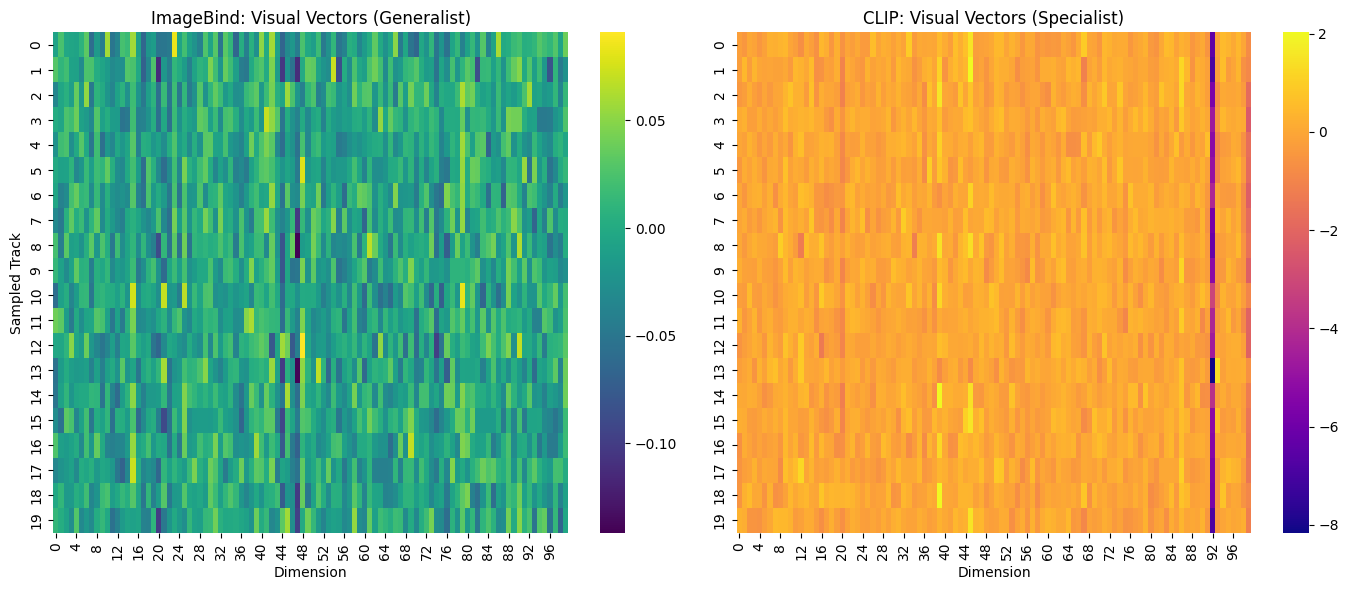

Per-encoder norm summary (dead-image detection):
  ImageBind    mean=1.0000  std=3.92e-08  rel_std=3.92e-08  pre_normalized=True  all-zero rows=0
  CLIP         mean=10.0477  std=9.72e-01  rel_std=9.67e-02  pre_normalized=False  all-zero rows=0


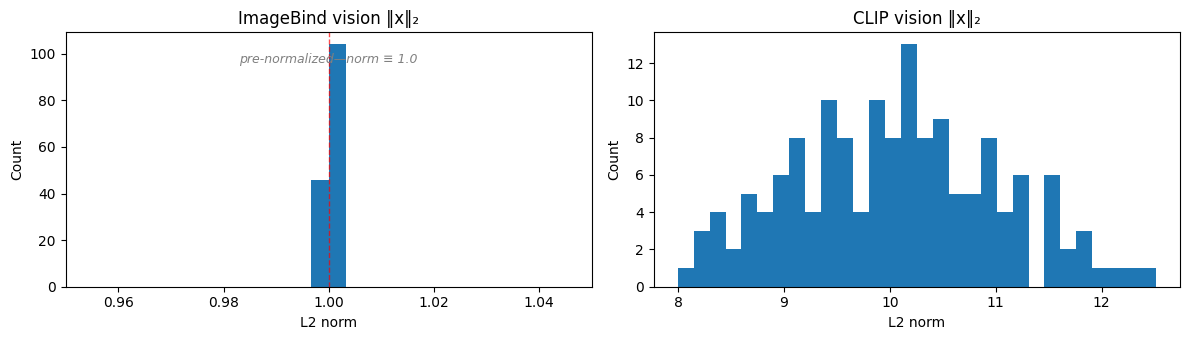

✅ Visual checks saved to /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/03_2026-04-21_20-33
✅ Notebook 03 complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Timestamped visual-check subfolder
stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
vis_out = os.path.join(VIS_DIR, f"{NOTEBOOK_ID}_{stamp}")
os.makedirs(vis_out, exist_ok=True)

image_ib   = np.load(os.path.join(EMBED_DIR, "image_ib_embeddings.npy"))
image_clip = np.load(os.path.join(EMBED_DIR, "image_clip_embeddings.npy"))

# ----- (a) Side-by-side embedding heatmaps (seeded random 20-track sample) -----
rng = np.random.RandomState(SEED)
idx = rng.choice(len(image_ib), size=20, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(image_ib[idx, :100],   ax=axes[0], cmap='viridis', cbar=True)
axes[0].set(title="ImageBind: Visual Vectors (Generalist)", xlabel="Dimension", ylabel="Sampled Track")
sns.heatmap(image_clip[idx, :100], ax=axes[1], cmap='plasma',  cbar=True)
axes[1].set(title="CLIP: Visual Vectors (Specialist)",      xlabel="Dimension")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "visual_embedding_comparison.png"), dpi=150)
plt.show()

# ----- (b) Per-track norm + dead-image diagnostics --------------------------
# ImageBind's vision head returns L2-normalized embeddings by default, so
# norm-based dead-image detection is useless on that arm (all norms = 1.0 ± eps).
# We detect the pre-normalized case and switch to an alternate check based on
# max-abs per row (a true dead row has all zeros → norm=0 AND max-abs=0).
norms_ib   = np.linalg.norm(image_ib,   axis=1)
norms_clip = np.linalg.norm(image_clip, axis=1)

def _summarize(name, norms, X):
    mean, std = float(norms.mean()), float(norms.std())
    rel_std = std / (mean + 1e-12)
    pre_normalized = rel_std < 1e-5
    n_zero_rows = int((np.abs(X).max(axis=1) < 1e-12).sum())
    print(f"  {name:12s} mean={mean:.4f}  std={std:.2e}  rel_std={rel_std:.2e}  "
          f"pre_normalized={pre_normalized}  all-zero rows={n_zero_rows}")
    return pre_normalized

print("Per-encoder norm summary (dead-image detection):")
ib_prenorm   = _summarize("ImageBind", norms_ib,   image_ib)
clip_prenorm = _summarize("CLIP",      norms_clip, image_clip)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (label, norms, is_prenorm) in zip(
    axes,
    [("ImageBind vision", norms_ib, ib_prenorm), ("CLIP vision", norms_clip, clip_prenorm)],
):
    if is_prenorm:
        # Force a sensible x-range around 1.0 so the spike is visible and labeled
        ax.hist(norms, bins=30, range=(0.95, 1.05))
        ax.set_xlim(0.95, 1.05)
        ax.axvline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(0.5, 0.92, "pre-normalized—norm ≡ 1.0",
                ha="center", va="top", transform=ax.transAxes,
                fontsize=9, color="gray", style="italic")
    else:
        ax.hist(norms, bins=30)
    ax.set(title=f"{label} ‖x‖₂", xlabel="L2 norm", ylabel="Count")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "vision_norms.png"), dpi=150)
plt.show()

print(f"✅ Visual checks saved to {vis_out}")
print("✅ Notebook 03 complete.")


In [ ]:
# print("Re-extracting ImageBind Vision embeddings to check for pre-normalization...")

# ib_chunks_recheck = []
# for i in range(0, len(image_paths), BATCH):
#     batch_paths = image_paths[i : i + BATCH]
#     batch_tensor = ib_data.load_and_transform_vision_data(batch_paths, device)
#     with torch.no_grad():
#         out = ib_model({ModalityType.VISION: batch_tensor})
#     ib_chunks_recheck.append(out[ModalityType.VISION].detach().cpu().numpy().astype(np.float32))
#     del batch_tensor, out
#     if device == "cuda":
#         torch.cuda.empty_cache()

# image_ib_recheck = np.concatenate(ib_chunks_recheck, axis=0)

# # Calculate L2 norms immediately after concatenation
# norms_ib_recheck = np.linalg.norm(image_ib_recheck, axis=1)

# print(f"   ImageBind vision (re-extracted) shape: {image_ib_recheck.shape}")
# print(f"   First 5 L2 norms of re-extracted ImageBind embeddings: {norms_ib_recheck[:5]}")
# print(f"   All re-extracted ImageBind embeddings have L2 norm = 1: {np.allclose(norms_ib_recheck, 1.0)}")

# if np.allclose(norms_ib_recheck, 1.0):
#     print("\nConclusion: The ImageBind embeddings are indeed L2 normalized by the ImageBind library itself (likely within `imagebind_model` or `ib_data.load_and_transform_vision_data`) before being returned. This means the code comment about saving 'UN-normalized' vectors is outdated or refers to a different context/version of the library.")
# else:
#     print("\nObservation: The re-extracted ImageBind embeddings are NOT L2 normalized by default. Further investigation into the exact version of the library or specific model configuration might be needed.")